In [1]:
from sys import path

path.append("..")

import os
from pathlib import Path

os.chdir(Path.cwd().parent)

In [2]:
import re
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import psutil

from src.graph_utils.reading import read_graph6, read_metadata
from src.descriptors.edge_descriptors import edge_descriptors_dict
from src.descriptors.node_descriptors import node_descriptors_dict
from src.collision_tests.comparison import TestOperator

from src.settings import Settings


In [3]:
read_graph6('graph5', output_format='networkit')

<generator object read_graph6 at 0x749ceebe45e0>

In [4]:
from src.graph_utils.dataset import Dataset

dataset = Dataset('graph5')

In [5]:
for filename in os.listdir(Settings.raw_datasets_dir):
    if '.txt' in filename:
        old_filename = os.path.join('raw_datasets', filename)
        new_filename = re.sub(r'.txt', '', old_filename)
        print(old_filename, new_filename)

        os.rename(old_filename, new_filename)

In [6]:
psutil.cpu_count()

4

In [7]:
single_features = [(k, ) for k in edge_descriptors_dict.keys()]

node_features = [(f, ) for f in list(filter(lambda k: 'ldp' not in k, node_descriptors_dict.keys()))]
node_features.extend([tuple(filter(lambda k: 'ldp' in k and 'normalized' not in k, node_descriptors_dict.keys()))])
node_features.extend([tuple(filter(lambda k: 'ldp' in k and ('normalized' in k or 'degree' in k), node_descriptors_dict.keys()))])

single_features.extend(node_features)

all_features = []

all_features.extend(single_features \
    + list(map(lambda params: tuple(map(lambda x: x + ':k_graph2', params)), single_features)) \
    + list(map(lambda params: tuple(map(lambda x: x + ':k_graph3', params)), single_features)) \
    + list(map(lambda params: tuple(map(lambda x: x + ':modk_graph3', params)), single_features)) \
)

all_features.extend(list(map(lambda features: tuple(x + k_graph for k_graph in ['',':k_graph2',':k_graph3'] for x in features), single_features)))

all_features


[('jaccard_index',),
 ('jaccard_index_normalized',),
 ('adamic_adar',),
 ('katz_index',),
 ('neighborhood_distance',),
 ('neighborhood_measure',),
 ('preferential_attachment',),
 ('resource_allocation',),
 ('same_community',),
 ('total_nieghbors',),
 ('algebraic_distance',),
 ('ari',),
 ('lds',),
 ('scan',),
 ('cn_quadrangle',),
 ('cn_triangle',),
 ('lss',),
 ('simmelian_sparsifier_np',),
 ('edge_betweenness',),
 ('edge_betweenness_normalized',),
 ('spanning_edge',),
 ('eigenvector_centrality',),
 ('closeness',),
 ('closeness_normalized',),
 ('degree_centrality',),
 ('degree_centrality_normalized',),
 ('katz_centrality',),
 ('lcc',),
 ('ldp_degree', 'ldp_min', 'ldp_max', 'ldp_mean', 'ldp_std'),
 ('ldp_degree',
  'ldp_min_normalized',
  'ldp_max_normalized',
  'ldp_mean_normalized',
  'ldp_std_normalized'),
 ('jaccard_index:k_graph2',),
 ('jaccard_index_normalized:k_graph2',),
 ('adamic_adar:k_graph2',),
 ('katz_index:k_graph2',),
 ('neighborhood_distance:k_graph2',),
 ('neighborhood_me

In [25]:
import os
from typing import List
from src.graph_utils.dataset import Dataset
from src.collision_tests.utils import TestParameters

arguments_list = []
datasets: List[Dataset] = []
# for dataset_name in ['graph5', 'graph6', 'graph7']:
# for dataset_name in ['regular']:

# for dataset_name in  list(map(lambda x: '.'.join(x.split('.')[:-1]), filter(lambda x: '.g6' in x, os.listdir(Settings.raw_datasets_dir))))[:15]:
# for dataset_name in ['sr351668',
#                     'selfcomp13',
#                     'graph8',
#                     'perfect6',
#                     # 'regular',
#                     'chordal8']:

for dataset_name in ['planar_conn.9',]:
    dataset = Dataset(name=dataset_name)
    datasets.append(dataset)
    if len(dataset) > 100_000:
        continue
    for features in all_features:
    
        features = features
        arguments_list.append(TestParameters(dataset_name=dataset_name,
                                    features=features))

In [26]:
for d in datasets:
    print(len(d),'\t', d.name)

71885 	 planar_conn.9


In [27]:
from tqdm import tqdm
for dataset in tqdm(datasets):
    dataset.generate_k_graph_cache(k=2)
    dataset.generate_k_graph_cache(k=3)
    dataset.generate_k_graph_cache(k=3, modified=True)


100%|██████████| 1/1 [00:00<00:00, 8665.92it/s]


In [28]:
test_operator = TestOperator(single_thread=False, batch_size=12)

test_operator.tests(arguments_list)

  0%|          | 0/6 [00:00<?, ?it/s]/teamspace/studios/this_studio/Analysis-of-graph-topological-descriptors-for-the-graph-isomorphism-problem/src/descriptors/node_descriptors.py:101: RuntimeWarning: invalid value encountered in divide
  return degree_matrix.sum(axis=1) / degrees
/teamspace/studios/this_studio/Analysis-of-graph-topological-descriptors-for-the-graph-isomorphism-problem/src/descriptors/node_descriptors.py:107: RuntimeWarning: invalid value encountered in divide
  mean_degree = degree_matrix.sum(axis=1) / degrees
/teamspace/studios/this_studio/Analysis-of-graph-topological-descriptors-for-the-graph-isomorphism-problem/src/descriptors/node_descriptors.py:108: RuntimeWarning: invalid value encountered in divide
  return (degree_matrix**2).sum(axis=1) / degrees - mean_degree**2
/teamspace/studios/this_studio/Analysis-of-graph-topological-descriptors-for-the-graph-isomorphism-problem/src/descriptors/node_descriptors.py:101: RuntimeWarning: invalid value encountered in divide

In [30]:
metadata = read_metadata()

In [31]:
from collections import Counter

def count_elements(row_array):
    if len(row_array) == 1 and row_array[0] == -1:
        return 0
    return len(row_array)

test_data = pd.read_parquet(Settings.processed_datasets_dir / 'table.parquet')
test_data['count'] = test_data['result'].apply(count_elements)

test_data['percentage'] = test_data.apply(lambda x: x['count'] / metadata[x['dataset_name']]['graph_count'], axis=1)

In [32]:
test_data = test_data.reset_index(drop=True)
test_data

,features,dataset_name,result,count,percentage
0,[jaccard_index],graph5,"[2, 5, 3, 6, 8, 4, 10, 13, 20, 11, 12, 21, 9, ...",18,0.529412
1,[jaccard_index_normalized],graph5,"[2, 5, 3, 6, 8, 4, 10, 13, 20, 15, 26]",11,0.323529
2,[adamic_adar],graph5,"[2, 5, 3, 6, 8, 4, 10, 13, 20, 15, 26]",11,0.323529
3,[katz_index],graph5,"[2, 5, 3, 6, 8, 4, 10, 13, 20, 11, 12, 21, 9, ...",18,0.529412
4,[neighborhood_distance],graph5,"[2, 5, 3, 6, 8, 4, 10, 13, 20, 15, 26]",11,0.323529
...,...,...,...,...,...
3745,"[degree_centrality_normalized, degree_centrali...",planar_conn.9,"[211, 215, 115, 236, 64847, 422, 430, 450, 455...",53115,0.738889
3746,"[katz_centrality, katz_centrality:k_graph2, ka...",planar_conn.9,"[1143, 2825, 2873, 2875, 5193, 5194, 6740, 678...",637,0.008861
3747,"[lcc, lcc:k_graph2, lcc:k_graph3]",planar_conn.9,"[3, 5, 7, 9, 11, 13, 33, 27, 32, 68, 97, 136, ...",16320,0.227029
3748,"[ldp_degree, ldp_degree:k_graph2, ldp_degree:k...",planar_conn.9,"[1143, 2825, 2873, 2875, 3072, 3080, 4036, 403...",2878,0.040036


In [33]:
test_data['result'].iloc[0]

array([ 2,  5,  3,  6,  8,  4, 10, 13, 20, 11, 12, 21,  9, 19, 16, 24, 15,
       26])

In [34]:

test_data['features'] = test_data['features'].astype('string').astype('category')
test_data.columns

Index(['features', 'dataset_name', 'result', 'count', 'percentage'], dtype='object')

In [35]:
test_data.sort_values('count').head(20)

,features,dataset_name,result,count,percentage
1925,['neighborhood_measure' 'neighborhood_measure:...,perfect8,[-1],0,0.0
1933,['scan' 'scan:k_graph2' 'scan:k_graph3'],perfect8,[-1],0,0.0
3271,['resource_allocation' 'resource_allocation:k_...,planar_conn.5,[-1],0,0.0
3270,['preferential_attachment' 'preferential_attac...,planar_conn.5,[-1],0,0.0
3267,['katz_index' 'katz_index:k_graph2' 'katz_inde...,planar_conn.5,[-1],0,0.0
3266,['adamic_adar' 'adamic_adar:k_graph2' 'adamic_...,planar_conn.5,[-1],0,0.0
3265,['jaccard_index_normalized' 'jaccard_index_nor...,planar_conn.5,[-1],0,0.0
3264,['jaccard_index' 'jaccard_index:k_graph2' 'jac...,planar_conn.5,[-1],0,0.0
2388,['edge_betweenness' 'edge_betweenness:k_graph2...,chordal6,[-1],0,0.0
1189,['edge_betweenness_normalized' 'edge_betweenne...,chordal8,[-1],0,0.0


In [ ]:
# data2d = test_data[~test_data['features'].str.contains('graph')].pivot(index="features", columns="dataset_name", values="percentage")
# data2d = test_data[test_data['features'].str.contains(':k_graph2')].pivot(index="features", columns="dataset_name", values="percentage")

data2d = test_data.pivot(index="features", columns="dataset_name", values="percentage")


data2d = data2d.sort_index()

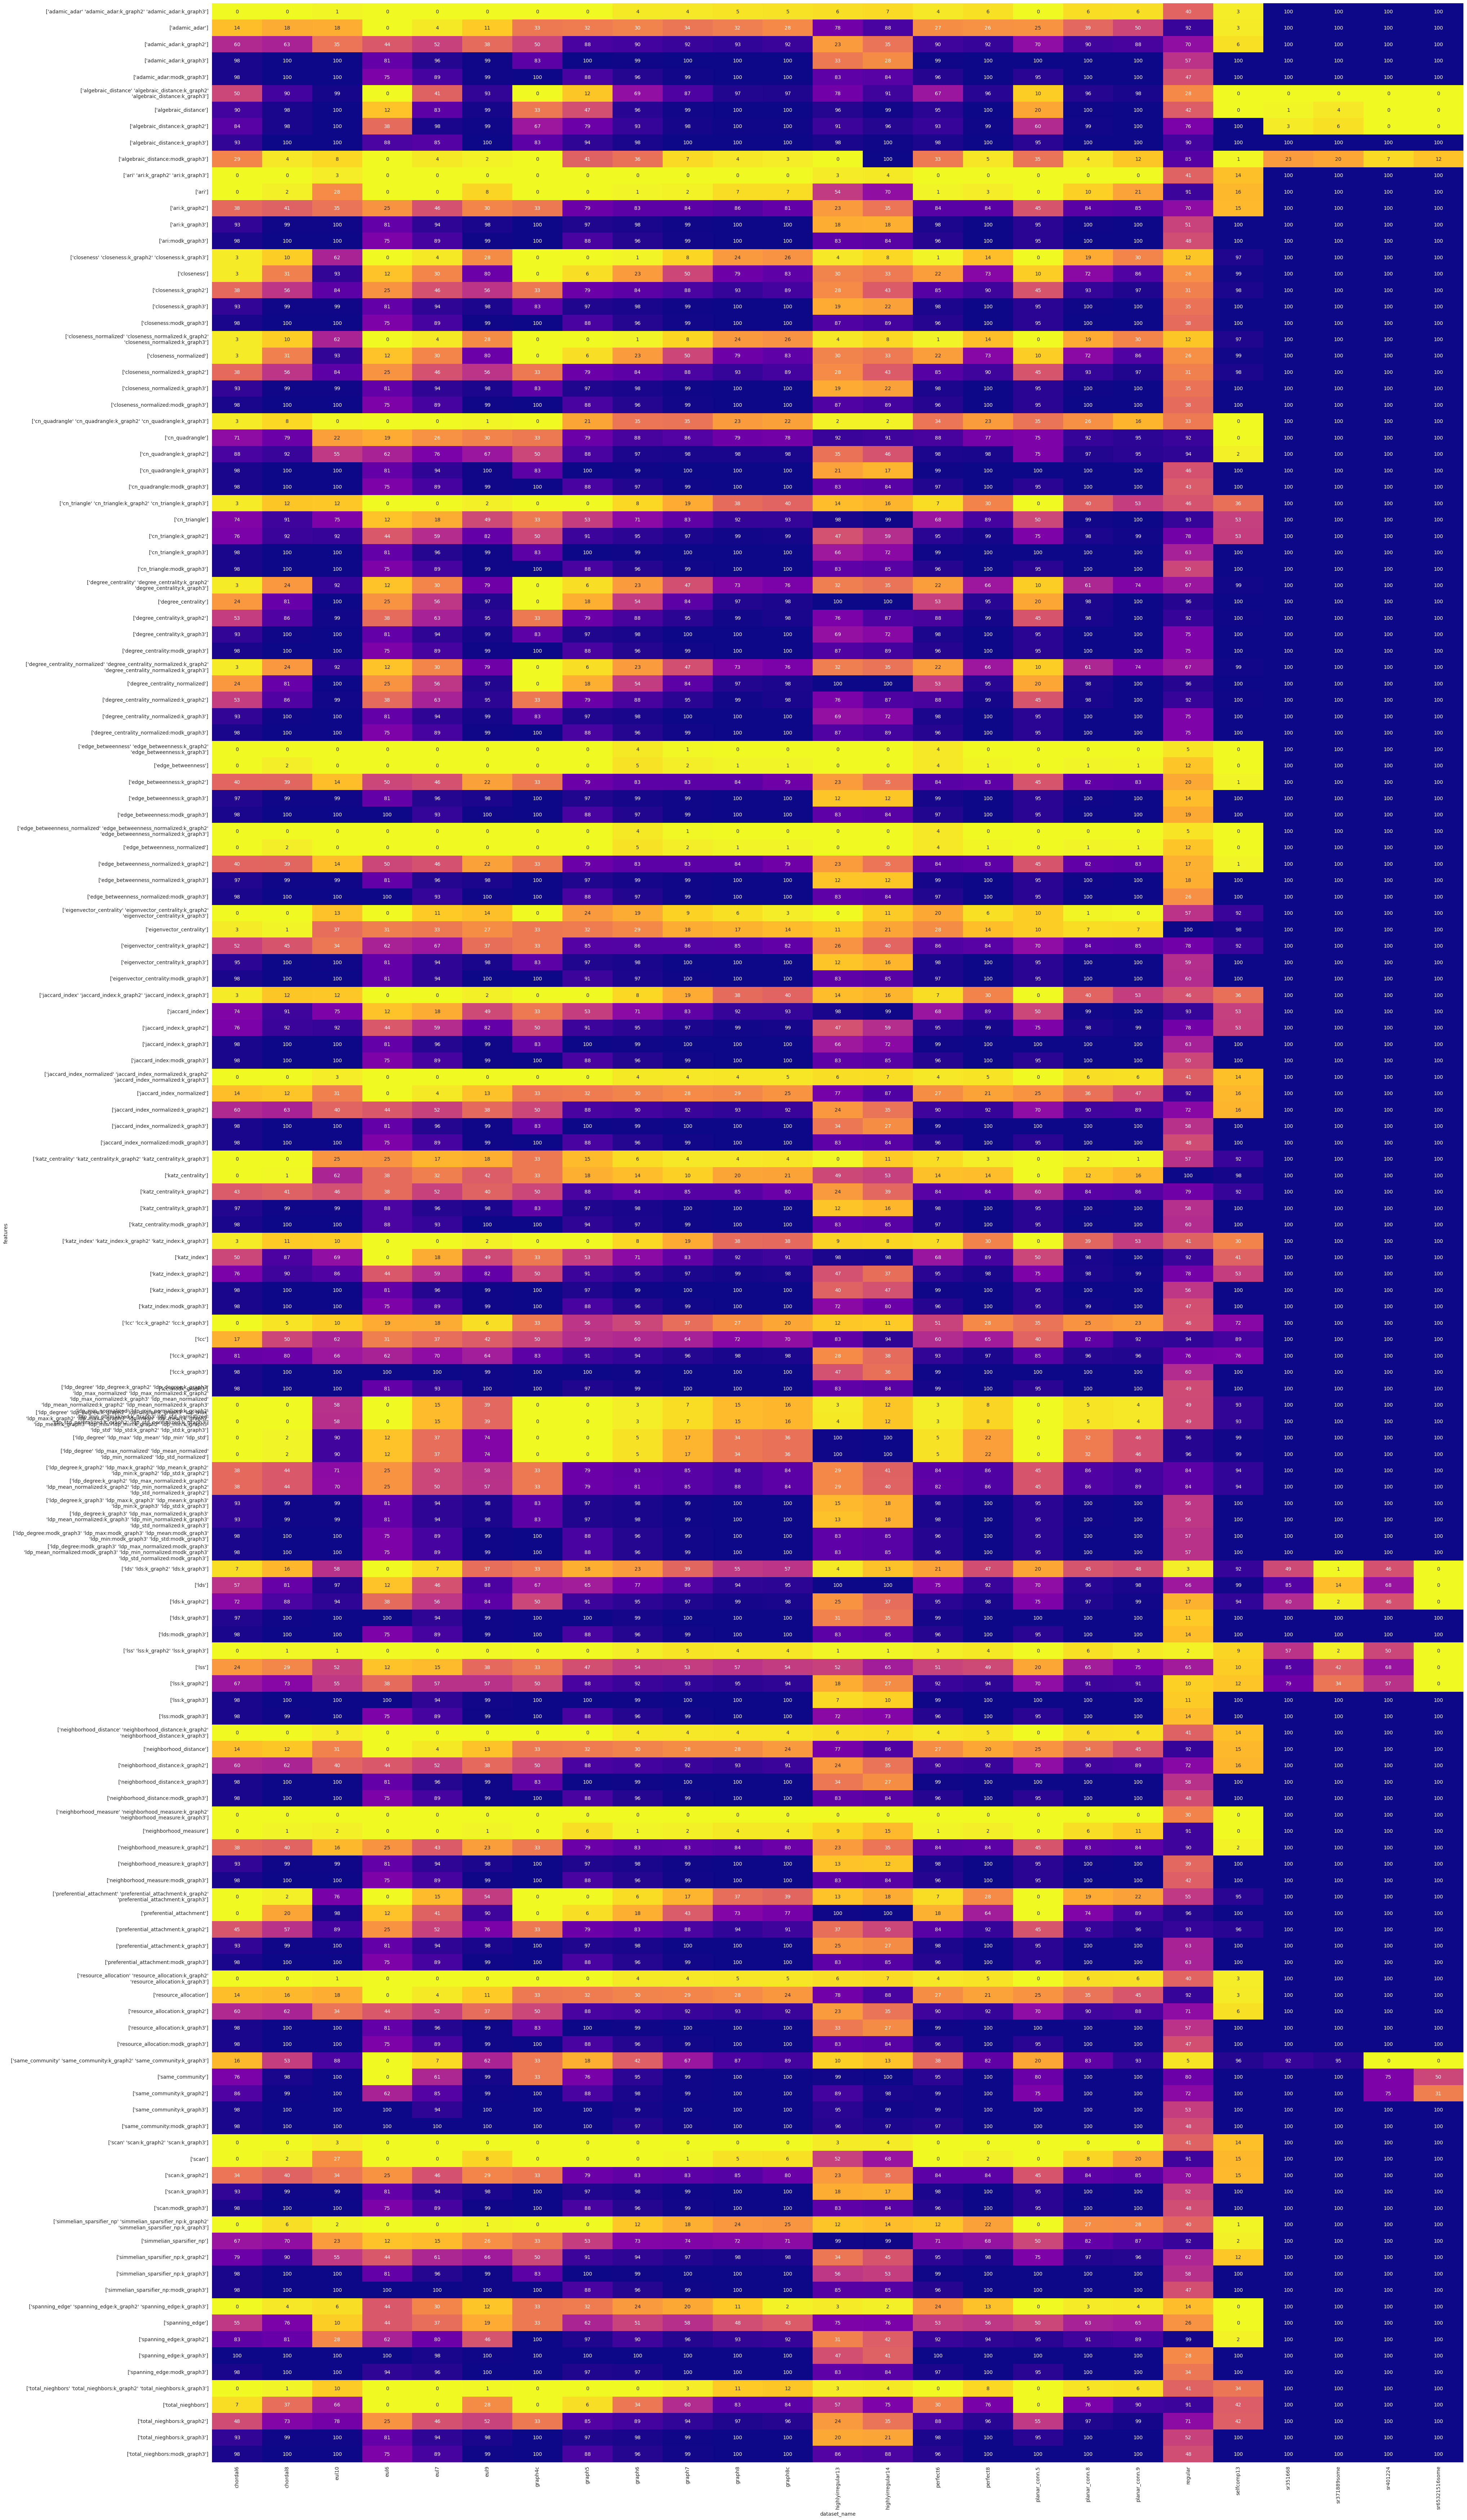

In [50]:

g = sns.heatmap(data=data2d, cmap='plasma_r', vmin=0, vmax=1, annot=np.round(data2d * 100, 1), fmt=".0f", cbar=False)
fig = plt.gcf()
fig.set_size_inches(40,70)
plt.tight_layout()

g.set_yticks(np.arange(data2d.shape[0]) + 0.5)

_ = g.set_yticklabels(data2d.index)

g.set_xticks(np.arange(data2d.shape[1]) + 0.5)

_ = g.set_xticklabels(data2d.columns)
